In [2]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import json
import pandas as pd

In [3]:
data_path = "./data.xml"; assert os.path.exists(data_path), "File does not exist: {}".format(data_path)
date_path = "./dates.json"; assert os.path.exists(date_path), "File does not exist: {}".format(date_path)

In [4]:
root = ET.parse(data_path).getroot()
dates = json.load(open(date_path, "r"))

sleep_data = [r for r in root.findall("Record")]
print("Total number of records: {}".format(len(sleep_data)))
print("Total days of data: {}".format(len(dates)))

Total number of records: 4140
Total days of data: 85


In [ ]:
def feature_extraction(dates, data):
    """
    Extracts the length of each stage of the sleep, as well as the start time and weekday, which are relevant to sleeping routines.
    This function adapts batch computation, which would be way faster than iterative approach.
    """
    raw_df = pd.DataFrame([r.attrib for r in data])
    
    raw_df["startDate"] = pd.to_datetime(raw_df["startDate"])
    raw_df["endDate"] = pd.to_datetime(raw_df["endDate"])
    raw_df["duration"] = (raw_df["endDate"] - raw_df["startDate"]).dt.total_seconds() / 60.0
    
    rows = []
    weekday_map = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu" :3, "Fri": 4, "Sat": 5, "Sun": 6}
    for weekday, indices in dates:
        session_slice = raw_df.iloc[indices]
        core = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepCore"]["duration"].sum()
        deep = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepDeep"]["duration"].sum()
        rem = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAsleepREM"]["duration"].sum()
        awake = session_slice[session_slice["value"] == "HKCategoryValueSleepAnalysisAwake"]["duration"].sum()
        
        start_hour = session_slice["startDate"].min().hour + session_slice["startDate"].min().minute / 60.0
        # The start hour is in 24 hours. In this case, there's huge risk that sleeping starting at noon and sleeping at early night will be clustered together.
        # To mitigate this issue, we can use sine transformation to capture the cyclical nature of time.
        start_sin = np.sin(2 * np.pi * start_hour / 24)
        
        rows.append([start_sin, core, deep, rem, awake, weekday_map[weekday]])
    df = pd.DataFrame(rows, columns=["start_sin", "CORE", "DEEP", "REM", "AWAKE", "weekday"])
    return df

def train_kmeans(df, n_clusters=5):
    df = df.dropna().copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    
    model = KMeans(n_clusters=n_clusters, random_state=42)
    df["cluster"] = model.fit_predict(X_scaled)
    return df, model, scaler

In [6]:
df = feature_extraction(dates, sleep_data)

In [7]:
# Provisional cluster number
N_CLUSTERS = 3

final_df, model, scaler = train_kmeans(df, n_clusters=N_CLUSTERS)
print(final_df.groupby('cluster').mean())

         start_time        CORE       DEEP         REM      AWAKE   weekday
cluster                                                                    
0          5.277536  338.360145  82.336957  171.578986  10.220290  2.347826
1          5.041892  136.520270  52.679730   54.472072   6.356306  4.891892
2          9.387681  129.802174  41.782609   40.538406  11.226087  1.521739


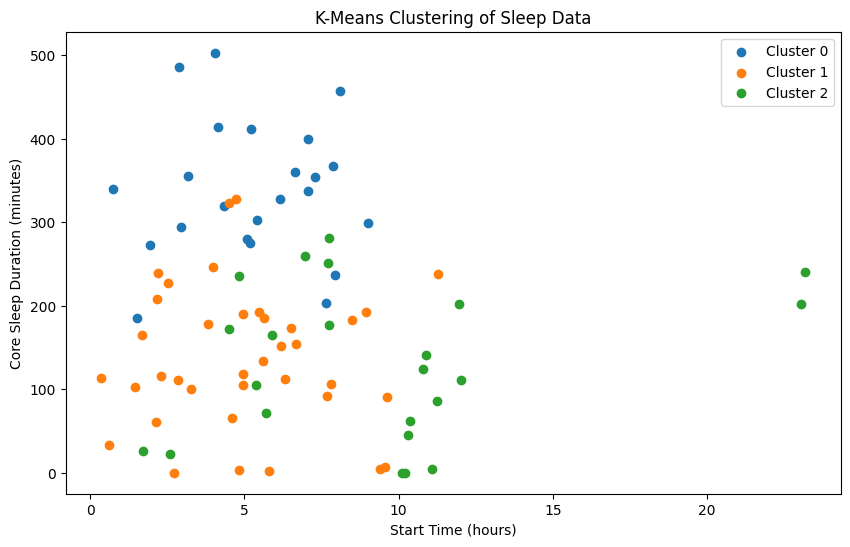

In [8]:
plt.figure(figsize=(10, 6))
for cluster in range(N_CLUSTERS):
    cluster_data = final_df[final_df['cluster'] == cluster]
    plt.scatter(cluster_data['start_time'], cluster_data['CORE'], label=f'Cluster {cluster}')
plt.xlabel('Start Time (hours)')
plt.ylabel('Core Sleep Duration (minutes)')
plt.title('K-Means Clustering of Sleep Data')
plt.legend()
plt.show()